In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    oob_score=True,
    bootstrap=True
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print("OOB Score:", model.oob_score_)


Accuracy: 0.9666666666666667
OOB Score: 0.95


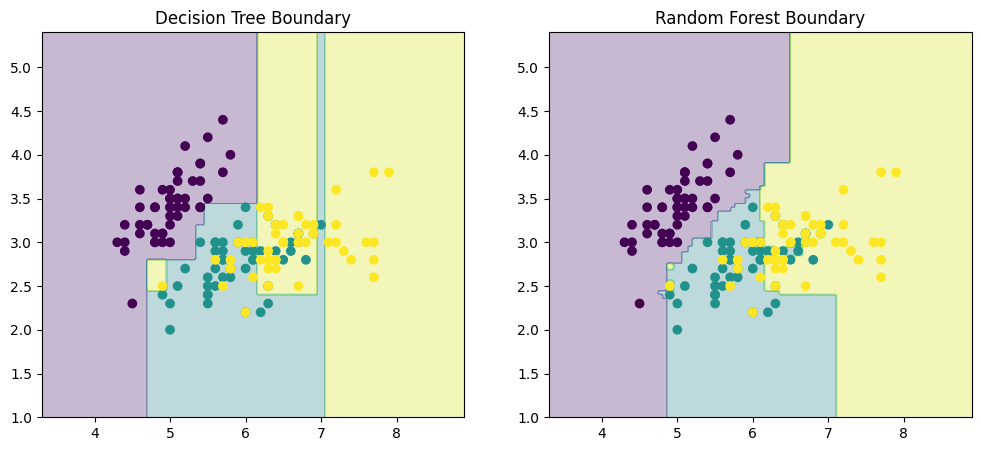

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Load data
data = load_iris()
X, y = data.data[:, :2], data.target  # only 2 features

# Models
tree = DecisionTreeClassifier(max_depth=5)
forest = RandomForestClassifier(n_estimators=50, max_depth=5)

tree.fit(X, y)
forest.fit(X, y)

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict
Z_tree = tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z_forest = forest.predict(np.c_[xx.ravel(), yy.ravel()])

Z_tree = Z_tree.reshape(xx.shape)
Z_forest = Z_forest.reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 5))

# Decision Tree
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_tree, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Decision Tree Boundary")

# Random Forest
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_forest, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Random Forest Boundary")

plt.show()